In [1]:
# ==============================================================
# 02_detector_bolas.py — YOLO multiclasse (branca/preta/lisa/listrada)
# Versão limpa: YOLO faz detecção E classificação.
# OpenCV HSV removido completamente.
# ==============================================================

# --- Célula 1: imports, caminhos e carga do modelo ---
import os
import cv2
import json
import glob
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

CAMINHO_BASE       = os.path.join(os.path.dirname(os.getcwd()), 'data')
CAMINHO_NORMALIZED = os.path.join(CAMINHO_BASE, 'normalized')
CAMINHO_OUTPUT     = os.path.join(CAMINHO_BASE, 'output')
CAMINHO_MODELO     = os.path.join(CAMINHO_BASE, '..', 'models', 'yolo_deteccao_bolas.pt')

modelo_yolo = YOLO(CAMINHO_MODELO)

# Ordem dos IDs deve bater exatamente com o data.yaml usado no treino.
# Roboflow exporta em ordem alfabética — confirme no seu data.yaml antes de usar.
NOMES_CLASSES = {0: 'branca', 1: 'lisa', 2: 'listrada', 3: 'preta'}

print('Modelo carregado:', CAMINHO_MODELO)
print('Classes:', NOMES_CLASSES)

Modelo carregado: /home/bridge/SinucaVision/data/../models/yolo_deteccao_bolas.pt
Classes: {0: 'branca', 1: 'lisa', 2: 'listrada', 3: 'preta'}


In [2]:
# --- Célula 2: função de detecção (YOLO faz tudo, sem HSV) ---
def detectar_bolas_e_cacapas(imagem, modelo, conf=0.35):
    """Roda o YOLO na imagem e retorna bolas + caçapas no formato padrão do pipeline."""
    altura, largura = imagem.shape[:2]
    resultados = {'cacapas': [], 'bolas': []}

    # Caçapas — posições fixas derivadas da homografia (não mudam)
    margem_x = int(largura * 0.02)
    margem_y = int(altura * 0.04)
    resultados['cacapas'] = [
        {'posicao': 'superior_esq',  'x': margem_x,            'y': margem_y},
        {'posicao': 'superior_meio', 'x': largura // 2,         'y': margem_y},
        {'posicao': 'superior_dir',  'x': largura - margem_x,   'y': margem_y},
        {'posicao': 'inferior_esq',  'x': margem_x,             'y': altura - margem_y},
        {'posicao': 'inferior_meio', 'x': largura // 2,         'y': altura - margem_y},
        {'posicao': 'inferior_dir',  'x': largura - margem_x,   'y': altura - margem_y},
    ]

    # Inferência YOLO — ele detecta E classifica de uma vez
    pred = modelo.predict(imagem, conf=conf, verbose=False)[0]

    for box in pred.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(largura, x2), min(altura, y2)

        classe_id = int(box.cls[0])
        tipo      = NOMES_CLASSES.get(classe_id, 'lisa')  # fallback seguro
        cx        = (x1 + x2) // 2
        cy        = (y1 + y2) // 2
        raio      = max((x2 - x1), (y2 - y1)) // 2

        resultados['bolas'].append({
            'tipo':      tipo,
            'x':         cx,
            'y':         cy,
            'raio':      raio,
            'confianca': round(float(box.conf[0]), 3),
        })

    return resultados

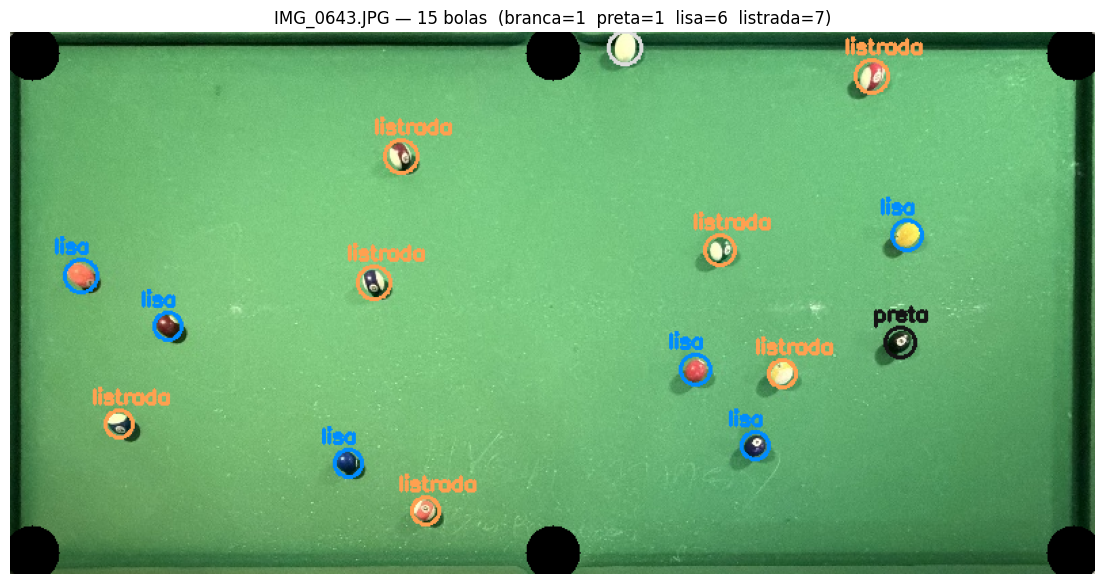

Salvo: /home/bridge/SinucaVision/data/output/IMG_0643/IMG_0643_balls.json


In [6]:
# --- Célula 3: testa numa imagem única e visualiza ---
nome_ficheiro = 'IMG_0643.JPG'
nome_base     = os.path.splitext(nome_ficheiro)[0]
caminho_img   = os.path.join(CAMINHO_NORMALIZED, nome_ficheiro)
imagem        = cv2.imread(caminho_img)

dados = detectar_bolas_e_cacapas(imagem, modelo_yolo)

COR_TIPO = {
    'branca':   (220, 220, 220),
    'preta':    (20,  20,  20 ),
    'lisa':     (255, 140,  0 ),
    'listrada': (80,  160, 255),
}

vis = imagem.copy()

for cacapa in dados['cacapas']:
    cv2.circle(vis, (cacapa['x'], cacapa['y']), 20, (0, 0, 0), -1)

for bola in dados['bolas']:
    cx, cy, raio, tipo = bola['x'], bola['y'], bola['raio'], bola['tipo']
    cor = COR_TIPO.get(tipo, (0, 255, 0))
    cv2.circle(vis, (cx, cy), raio, cor, 2)
    cv2.putText(vis, tipo, (cx - 20, cy - raio - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, cor, 2)

n_b = sum(1 for b in dados['bolas'] if b['tipo'] == 'branca')
n_p = sum(1 for b in dados['bolas'] if b['tipo'] == 'preta')
n_l = sum(1 for b in dados['bolas'] if b['tipo'] == 'lisa')
n_s = sum(1 for b in dados['bolas'] if b['tipo'] == 'listrada')

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f'{nome_ficheiro} — {len(dados["bolas"])} bolas  '
          f'(branca={n_b}  preta={n_p}  lisa={n_l}  listrada={n_s})')
plt.axis('off')
plt.show()

# Salva JSON
pasta = os.path.join(CAMINHO_OUTPUT, nome_base)
os.makedirs(pasta, exist_ok=True)
caminho_json = os.path.join(pasta, f'{nome_base}_balls.json')
with open(caminho_json, 'w', encoding='utf-8') as f:
    json.dump(dados, f, indent=4, ensure_ascii=False)
print(f'Salvo: {caminho_json}')

In [ ]:
# --- Célula 4: batch — processa todas as imagens normalizadas ---
imagens = sorted(
    glob.glob(os.path.join(CAMINHO_NORMALIZED, '*.JPG')) +
    glob.glob(os.path.join(CAMINHO_NORMALIZED, '*.jpg'))
)
print(f'Imagens encontradas: {len(imagens)}')

for caminho_img in imagens:
    nome_ficheiro = os.path.basename(caminho_img)
    nome_base     = os.path.splitext(nome_ficheiro)[0]
    imagem = cv2.imread(caminho_img)
    if imagem is None:
        print(f'  [ERRO] {nome_ficheiro}')
        continue

    dados   = detectar_bolas_e_cacapas(imagem, modelo_yolo)
    bolas   = dados['bolas']
    n_b = sum(1 for b in bolas if b['tipo'] == 'branca')
    n_p = sum(1 for b in bolas if b['tipo'] == 'preta')
    n_l = sum(1 for b in bolas if b['tipo'] == 'lisa')
    n_s = sum(1 for b in bolas if b['tipo'] == 'listrada')

    pasta = os.path.join(CAMINHO_OUTPUT, nome_base)
    os.makedirs(pasta, exist_ok=True)
    caminho_json = os.path.join(pasta, f'{nome_base}_balls.json')
    with open(caminho_json, 'w', encoding='utf-8') as f:
        json.dump(dados, f, indent=4, ensure_ascii=False)

    aviso = '' if n_b == 1 else '  ⚠'
    print(f'  ✓  {nome_ficheiro}: {len(bolas)} bolas '
          f'(B={n_b} P={n_p} L={n_l} S={n_s}){aviso}')

print(f'\nConcluído. JSONs em data/output/<nome>/')

In [ ]:
# --- Célula 5: visualização em lote a partir dos JSONs ---
arquivos_json = sorted(glob.glob(
    os.path.join(CAMINHO_OUTPUT, '**', '*_balls.json'), recursive=True))
print(f'JSONs encontrados: {len(arquivos_json)}')

for caminho_json in arquivos_json:
    nome_base   = os.path.basename(caminho_json).replace('_balls.json', '')
    pasta_saida = os.path.dirname(caminho_json)

    caminho_img = os.path.join(CAMINHO_NORMALIZED, nome_base + '.JPG')
    if not os.path.exists(caminho_img):
        caminho_img = os.path.join(CAMINHO_NORMALIZED, nome_base + '.jpg')
    imagem = cv2.imread(caminho_img)
    if imagem is None:
        continue

    with open(caminho_json) as f:
        dados = json.load(f)

    bolas = dados['bolas']
    n_b = sum(1 for b in bolas if b['tipo'] == 'branca')
    n_p = sum(1 for b in bolas if b['tipo'] == 'preta')
    n_l = sum(1 for b in bolas if b['tipo'] == 'lisa')
    n_s = sum(1 for b in bolas if b['tipo'] == 'listrada')

    vis = cv2.cvtColor(imagem.copy(), cv2.COLOR_BGR2RGB)

    for cacapa in dados['cacapas']:
        cv2.circle(vis, (cacapa['x'], cacapa['y']), 12, (30, 30, 30), -1)
        cv2.circle(vis, (cacapa['x'], cacapa['y']), 12, (180, 180, 180), 2)

    for idx, bola in enumerate(bolas, 1):
        cx, cy = bola['x'], bola['y']
        raio   = bola.get('raio', 15)
        cor    = COR_TIPO.get(bola['tipo'], (200, 200, 200))
        cv2.circle(vis, (cx, cy), raio + 3, cor, 2)
        cv2.putText(vis, str(idx), (cx - 5, cy - raio - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, cor, 1, cv2.LINE_AA)

    aviso = '' if n_b == 1 else '  ⚠ BRANCA NÃO DETECTADA / DUPLICADA'
    titulo = (f'{nome_base}  |  {len(bolas)} bolas  '
              f'(branca={n_b}  preta={n_p}  lisa={n_l}  listrada={n_s}){aviso}')

    plt.figure(figsize=(12, 7))
    plt.imshow(vis)
    plt.title(titulo, fontsize=11)
    plt.axis('off')
    plt.tight_layout()
    caminho_viz = os.path.join(pasta_saida, f'{nome_base}_viz.png')
    plt.savefig(caminho_viz, dpi=130, bbox_inches='tight')
    plt.close()
    print(f'  ✓  {nome_base}_viz.png')

print('Visualizações salvas em data/output/<nome>/')